In [ ]:
import shutil

def check_disk_gb():
    """Return free disk space in GB."""
    return shutil.disk_usage("/").free / (1024**3)

In [ ]:
# ============================================================
# CELL 1 — Mount Drive + check AI-TOD structure
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

import json
from pathlib import Path
from collections import defaultdict

# ── Your AI-TOD paths on Drive ────────────────────────────────
AITOD_TRAIN = Path("/content/drive/MyDrive/AI-TOD_train")
AITOD_TEST  = Path("/content/drive/MyDrive/AI-TOD_test")

print("📂 AI-TOD Train structure:")
for p in sorted(AITOD_TRAIN.rglob("*")):
    if p.is_dir():
        n = len(list(p.glob("*")))
        if n > 0:
            print(f"  {p.relative_to(AITOD_TRAIN)}  ({n} files)")

print("\n📂 AI-TOD Test structure:")
for p in sorted(AITOD_TEST.rglob("*")):
    if p.is_dir():
        n = len(list(p.glob("*")))
        if n > 0:
            print(f"  {p.relative_to(AITOD_TEST)}  ({n} files)")

# Check annotation format
print("\n🔍 Annotation format:")
json_files = list(AITOD_TRAIN.rglob("*.json")) + \
             list(AITOD_TEST.rglob("*.json"))
txt_files  = list(AITOD_TRAIN.rglob("*.txt")) + \
             list(AITOD_TEST.rglob("*.txt"))
print(f"  JSON files: {len(json_files)}")
print(f"  TXT files : {len(txt_files)}")

if json_files:
    with open(json_files[0]) as f:
        data = json.load(f)
    print(f"\n  Keys: {list(data.keys())[:6]}")
    if "categories" in data:
        print(f"  Categories: {[c['name'] for c in data['categories']]}")
    if "images" in data:
        print(f"  Total images: {len(data['images'])}")
    if "annotations" in data:
        print(f"  Total annotations: {len(data['annotations'])}")

if txt_files:
    sample = open(txt_files[0]).readline().strip()
    print(f"\n  Sample TXT label: '{sample}'")

Mounted at /content/drive
📂 AI-TOD Train structure:
  images  (19462 files)
  labels  (19462 files)

📂 AI-TOD Test structure:
  images  (8493 files)
  labels  (8493 files)

🔍 Annotation format:
  JSON files: 0
  TXT files : 27955

  Sample TXT label: '3 0.2075 0.92875 0.22125 0.92875 0.22125 0.91375 0.2075 0.91375 0.2075 0.92875'


In [ ]:
# ============================================================
# CELL 2 — Config: how many images to sample
# ============================================================

# ── Sampling limits ────────────────────────────────────────────
MAX_TRAIN = 2000   # from AI-TOD train
MAX_VAL   =  500   # from AI-TOD test (used as val)

# ── Output path on Drive ───────────────────────────────────────
OUTPUT_DIR = Path("/content/drive/MyDrive/VisDrone_Pipeline/aitod_sampled")

# AI-TOD class mapping (COCO category_id → YOLO 0-based index)
# Categories: airplane, bridge, storage-tank, ship,
#             swimming-pool, vehicle, person, wind-mill
AT_CAT_TO_YOLO = {1:0, 2:1, 3:2, 4:3, 5:4, 6:5, 7:6, 8:7}
AT_CLASSES     = ["airplane", "bridge", "storage-tank", "ship",
                  "swimming-pool", "vehicle", "person", "wind-mill"]

import random
SEED = 42
random.seed(SEED)

print(f"✅ Config ready")
print(f"   MAX_TRAIN : {MAX_TRAIN}")
print(f"   MAX_VAL   : {MAX_VAL}")
print(f"   Output    : {OUTPUT_DIR}")

✅ Config ready
   MAX_TRAIN : 2000
   MAX_VAL   : 500
   Output    : /content/drive/MyDrive/VisDrone_Pipeline/aitod_sampled


In [ ]:
# ============================================================
# CELL 3 — Convert AI-TOD OBB format → standard YOLO
# OBB format: class x1 y1 x2 y2 x3 y3 x4 y4
# YOLO format: class cx cy w h (normalised, axis-aligned bbox)
# ============================================================
import cv2, shutil, random
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

AITOD_TRAIN   = Path("/content/drive/MyDrive/AI-TOD_train")
OUTPUT_DIR    = Path("/content/drive/MyDrive/VisDrone_Pipeline/aitod_sampled")
MAX_TRAIN     = 2000
SEED          = 42

# ── AI-TOD class IDs found: 1,2,3,6 (1-based) ───────────────
# Map to 0-based YOLO indices
# From AI-TOD paper: 1=airplane, 2=bridge, 3=storage-tank,
#                    4=ship, 5=swimming-pool, 6=vehicle,
#                    7=person, 8=wind-mill
AT_CAT_TO_YOLO = {
    1: 0,   # airplane
    2: 1,   # bridge
    3: 2,   # storage-tank
    4: 3,   # ship
    5: 4,   # swimming-pool
    6: 5,   # vehicle
    7: 6,   # person
    8: 7,   # wind-mill
}
AT_CLASSES = ["airplane","bridge","storage-tank","ship",
              "swimming-pool","vehicle","person","wind-mill"]

src_img_dir = AITOD_TRAIN / "images"
src_lbl_dir = AITOD_TRAIN / "labels"

out_img_dir = OUTPUT_DIR / "train" / "images"
out_lbl_dir = OUTPUT_DIR / "train" / "labels"
out_img_dir.mkdir(parents=True, exist_ok=True)
out_lbl_dir.mkdir(parents=True, exist_ok=True)

def obb_to_aabb(x1,y1,x2,y2,x3,y3,x4,y4):
    """
    Convert 4-corner OBB to axis-aligned bounding box.
    Returns (cx, cy, w, h) all normalised 0-1.
    Input coords are already normalised 0-1.
    """
    xs = [x1,x2,x3,x4]
    ys = [y1,y2,y3,y4]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)
    cx = (xmin + xmax) / 2
    cy = (ymin + ymax) / 2
    w  = xmax - xmin
    h  = ymax - ymin
    return cx, cy, w, h

def convert_obb_file(lbl_path, cat_to_yolo):
    """
    Parse one OBB label file and return YOLO lines.
    Handles: class x1 y1 x2 y2 x3 y3 x4 y4  (9 values)
    """
    lines_out = []
    for line in lbl_path.read_text().strip().split("\n"):
        parts = line.strip().split()
        if len(parts) < 9:
            continue
        try:
            cat_id = int(parts[0])
            coords = [float(v) for v in parts[1:9]]
        except ValueError:
            continue
        if cat_id not in cat_to_yolo:
            continue
        yolo_cls = cat_to_yolo[cat_id]
        cx, cy, w, h = obb_to_aabb(*coords)
        # Clamp
        cx = max(0.001, min(0.999, cx))
        cy = max(0.001, min(0.999, cy))
        w  = max(0.001, min(0.999, w))
        h  = max(0.001, min(0.999, h))
        lines_out.append(
            f"{yolo_cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
    return lines_out

# Sample MAX_TRAIN images
all_imgs = sorted(src_img_dir.glob("*.jpg")) + \
           sorted(src_img_dir.glob("*.png"))
random.seed(SEED)
random.shuffle(all_imgs)
sampled = all_imgs[:MAX_TRAIN]

print(f"Total available : {len(all_imgs)}")
print(f"Sampling        : {len(sampled)}")
print(f"Drive free      : {check_disk_gb():.1f} GB")
print()

converted = skipped = empty = 0
for img_path in tqdm(sampled, desc="Converting OBB→YOLO"):
    stem     = img_path.stem
    lbl_path = src_lbl_dir / (stem + ".txt")

    if not lbl_path.exists():
        skipped += 1
        continue

    # Skip if already done
    dst_img = out_img_dir / f"{stem}.jpg"
    dst_lbl = out_lbl_dir / f"{stem}.txt"
    if dst_img.exists() and dst_lbl.exists():
        converted += 1
        continue

    # Disk guard
    if check_disk_gb() < 1.5:
        print(f"⚠️  Low disk — stopping at {converted}")
        break

    yolo_lines = convert_obb_file(lbl_path, AT_CAT_TO_YOLO)
    if not yolo_lines:
        empty += 1
        continue

    shutil.copy(img_path, dst_img)
    dst_lbl.write_text("\n".join(yolo_lines))
    converted += 1

n_img = len(list(out_img_dir.glob("*.jpg")))
n_lbl = len(list(out_lbl_dir.glob("*.txt")))
print(f"\n✅ Converted : {converted}")
print(f"   Skipped   : {skipped}  (no label file)")
print(f"   Empty     : {empty}   (no matching classes)")
print(f"   Images    : {n_img}")
print(f"   Labels    : {n_lbl}")
print(f"   Match     : {'✅' if n_img==n_lbl else '❌'}")
print(f"   Drive free: {check_disk_gb():.1f} GB")

Total available : 19462
Sampling        : 2000
Drive free      : 65.4 GB



Converting OBB→YOLO:   0%|          | 0/2000 [00:00<?, ?it/s]


✅ Converted : 1996
   Skipped   : 0  (no label file)
   Empty     : 4   (no matching classes)
   Images    : 1996
   Labels    : 1996
   Match     : ✅
   Drive free: 65.0 GB


In [ ]:
# ============================================================
# CELL 4 — Convert AI-TOD TEST → YOLO val split
# Same OBB format
# ============================================================
AITOD_TEST = Path("/content/drive/MyDrive/AI-TOD_test")
MAX_VAL    = 500

# Check test structure first
print("AI-TOD Test structure:")
for p in sorted(AITOD_TEST.rglob("*")):
    if p.is_dir():
        n_jpg = len(list(p.glob("*.jpg")))+len(list(p.glob("*.png")))
        n_txt = len(list(p.glob("*.txt")))
        if n_jpg + n_txt > 0:
            print(f"  📁 {p.relative_to(AITOD_TEST)}")
            print(f"       jpg/png:{n_jpg}  txt:{n_txt}")

# Sample label check
test_txts = list(AITOD_TEST.rglob("*.txt"))
if test_txts:
    sample = test_txts[0].read_text().strip().split("\n")[0]
    print(f"\nSample test label: '{sample}'")
    print(f"Values count     : {len(sample.split())}")

AI-TOD Test structure:


In [ ]:
# ============================================================
# CELL 4 — Sample + Convert AI-TOD Test → YOLO (used as val)
# ============================================================
print("="*55)
print("  Processing AI-TOD TEST (→ used as val)")
print("="*55)
print(f"  Drive free: {check_disk_gb():.1f} GB")

out_val_img = OUTPUT_DIR / "val" / "images"
out_val_lbl = OUTPUT_DIR / "val" / "labels"

# Try COCO JSON
test_jsons = list(AITOD_TEST.rglob("*.json"))
test_imgs  = ([d for d in AITOD_TEST.rglob("*")
               if d.is_dir() and "image" in d.name.lower()]
              or [AITOD_TEST])

if test_jsons:
    print(f"  Format: COCO JSON  ({test_jsons[0].name})")
    img_dir = test_imgs[0] if test_imgs else AITOD_TEST
    n_val   = convert_coco_split(
        test_jsons[0], img_dir,
        out_val_img, out_val_lbl,
        AT_CAT_TO_YOLO, MAX_VAL
    )
else:
    lbl_dirs = [d for d in AITOD_TEST.rglob("*")
                if d.is_dir() and "label" in d.name.lower()]
    img_dirs = [d for d in AITOD_TEST.rglob("*")
                if d.is_dir() and "image" in d.name.lower()]
    if lbl_dirs and img_dirs:
        print(f"  Format: YOLO TXT")
        identity = {i: i for i in range(8)}
        n_val    = convert_yolo_split(
            img_dirs[0], lbl_dirs[0],
            out_val_img, out_val_lbl,
            identity, MAX_VAL
        )
    else:
        print("  ❌ Cannot detect format — check AITOD_TEST path")
        n_val = 0

print(f"\n  Val images saved: {len(list(out_val_img.glob('*.jpg')))}")
print(f"  Drive free: {check_disk_gb():.1f} GB")

  Processing AI-TOD TEST (→ used as val)
  Drive free: 65.0 GB
  ❌ Cannot detect format — check AITOD_TEST path

  Val images saved: 0
  Drive free: 65.0 GB


In [ ]:
# ── Run test conversion after verifying structure above ───────
test_img_dir = AITOD_TEST / "images"
test_lbl_dir = AITOD_TEST / "labels"

# Fallback: if test has different folder names
if not test_img_dir.exists():
    test_img_candidates = [d for d in AITOD_TEST.rglob("*")
                           if d.is_dir() and
                           len(list(d.glob("*.jpg"))) > 0]
    test_lbl_candidates = [d for d in AITOD_TEST.rglob("*")
                           if d.is_dir() and
                           len(list(d.glob("*.txt"))) > 0]
    test_img_dir = test_img_candidates[0] if test_img_candidates else AITOD_TEST
    test_lbl_dir = test_lbl_candidates[0] if test_lbl_candidates else AITOD_TEST

out_val_img = OUTPUT_DIR / "val" / "images"
out_val_lbl = OUTPUT_DIR / "val" / "labels"
out_val_img.mkdir(parents=True, exist_ok=True)
out_val_lbl.mkdir(parents=True, exist_ok=True)

all_test_imgs = sorted(test_img_dir.glob("*.jpg")) + \
                sorted(test_img_dir.glob("*.png"))
random.seed(SEED)
random.shuffle(all_test_imgs)
sampled_val = all_test_imgs[:MAX_VAL]

print(f"Test images available : {len(all_test_imgs)}")
print(f"Sampling              : {len(sampled_val)}")

converted_val = skipped_val = empty_val = 0
for img_path in tqdm(sampled_val, desc="Converting val"):
    stem     = img_path.stem
    lbl_path = test_lbl_dir / (stem + ".txt")
    if not lbl_path.exists():
        skipped_val += 1
        continue
    dst_img = out_val_img / f"{stem}.jpg"
    dst_lbl = out_val_lbl / f"{stem}.txt"
    if dst_img.exists() and dst_lbl.exists():
        converted_val += 1
        continue
    if check_disk_gb() < 1.5:
        print(f"⚠️  Low disk — stopping")
        break
    yolo_lines = convert_obb_file(lbl_path, AT_CAT_TO_YOLO)
    if not yolo_lines:
        empty_val += 1
        continue
    shutil.copy(img_path, dst_img)
    dst_lbl.write_text("\n".join(yolo_lines))
    converted_val += 1

n_img = len(list(out_val_img.glob("*.jpg")))
n_lbl = len(list(out_val_lbl.glob("*.txt")))
print(f"\n✅ Val converted : {converted_val}")
print(f"   Skipped      : {skipped_val}")
print(f"   Empty        : {empty_val}")
print(f"   Images       : {n_img}")
print(f"   Labels       : {n_lbl}")
print(f"   Match        : {'✅' if n_img==n_lbl else '❌'}")

Test images available : 0
Sampling              : 0


Converting val: 0it [00:00, ?it/s]


✅ Val converted : 0
   Skipped      : 0
   Empty        : 0
   Images       : 0
   Labels       : 0
   Match        : ✅


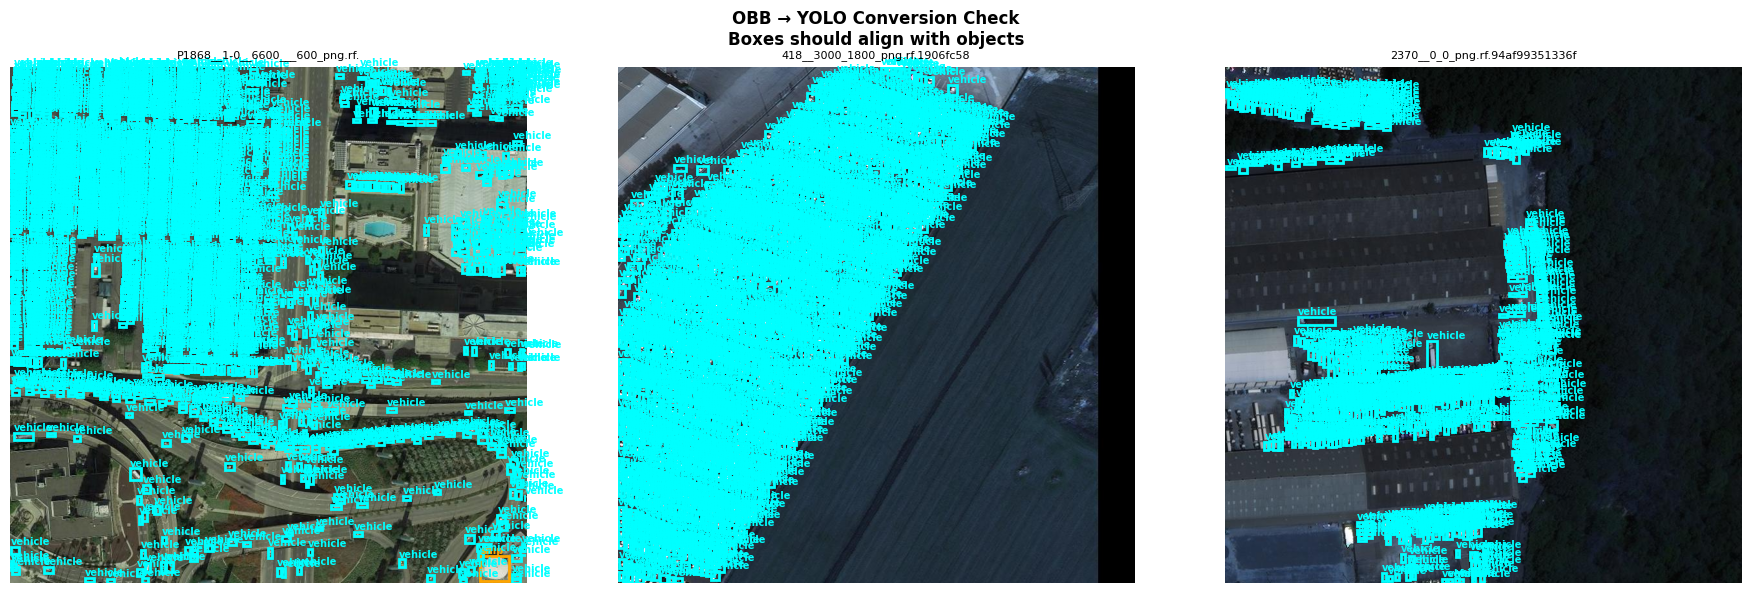

✅ Visual check saved


In [ ]:
# ============================================================
# CELL 5 — Verify OBB→YOLO conversion visually
# ============================================================
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

out_img_dir = OUTPUT_DIR / "train" / "images"
out_lbl_dir = OUTPUT_DIR / "train" / "labels"

# Pick 3 images with the most annotations
sample_imgs = sorted(
    out_img_dir.glob("*.jpg"),
    key=lambda p: len((out_lbl_dir/(p.stem+".txt"))
                      .read_text().strip().split("\n"))
                  if (out_lbl_dir/(p.stem+".txt")).exists() else 0,
    reverse=True
)[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
COLORS = ["red","blue","green","orange","purple",
          "cyan","magenta","yellow"]

for ax, img_path in zip(axes, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(img_path)),
                       cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    ax.imshow(img)

    lbl_path = out_lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().split("\n"):
            p = line.strip().split()
            if len(p) != 5:
                continue
            cls = int(p[0])
            cx,cy,w,h = [float(x) for x in p[1:]]
            x1 = (cx - w/2) * W
            y1 = (cy - h/2) * H
            rect = patches.Rectangle(
                (x1, y1), w*W, h*H,
                linewidth=2,
                edgecolor=COLORS[cls % len(COLORS)],
                facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1-3, AT_CLASSES[cls],
                    color=COLORS[cls % len(COLORS)],
                    fontsize=7, fontweight="bold")

    ax.set_title(img_path.name[:30], fontsize=8)
    ax.axis("off")

plt.suptitle("OBB → YOLO Conversion Check\n"
             "Boxes should align with objects",
             fontweight="bold")
plt.tight_layout()
plt.savefig("/content/obb_conversion_check.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("✅ Visual check saved")

In [ ]:
# ============================================================
# CELL 6 — Final summary + class distribution
# ============================================================
from collections import defaultdict

print("="*55)
print("  FINAL SUMMARY")
print("="*55)

total_bytes = sum(
    f.stat().st_size
    for f in OUTPUT_DIR.rglob("*") if f.is_file()
)

for split in ["train", "val"]:
    img_dir = OUTPUT_DIR / split / "images"
    lbl_dir = OUTPUT_DIR / split / "labels"
    n_img   = len(list(img_dir.glob("*.jpg")))
    n_lbl   = len(list(lbl_dir.glob("*.txt")))
    ok      = "✅" if n_img == n_lbl else "❌"
    print(f"\n  {ok} [{split}]  {n_img} images  {n_lbl} labels")

    counts = defaultdict(int)
    for lbl in lbl_dir.glob("*.txt"):
        for line in lbl.read_text().strip().split("\n"):
            p = line.strip().split()
            if len(p) == 5:
                counts[int(p[0])] += 1

    for cls_id, name in enumerate(AT_CLASSES):
        if counts[cls_id] > 0:
            bar = "█" * min(30, counts[cls_id] // 20)
            print(f"       {cls_id} {name:<16} "
                  f"{counts[cls_id]:>6,}  {bar}")

print(f"\n  Total size : {total_bytes/1e9:.2f} GB")
print(f"  Drive free : {check_disk_gb():.1f} GB")
print(f"  Output     : {OUTPUT_DIR}")
print(f"\n  ✅ Ready to upload to Kaggle as dataset")
print(f"     Kaggle → Datasets → New → upload aitod_sampled/")

  FINAL SUMMARY

  ✅ [train]  1996 images  1996 labels
       0 airplane             83  ████
       1 bridge            2,124  ██████████████████████████████
       2 storage-tank      2,287  ██████████████████████████████
       3 ship                675  ██████████████████████████████
       4 swimming-pool        43  ██
       5 vehicle          46,690  ██████████████████████████████
       6 person               54  ██

  ✅ [val]  0 images  0 labels

  Total size : 0.18 GB
  Drive free : 65.0 GB
  Output     : /content/drive/MyDrive/VisDrone_Pipeline/aitod_sampled

  ✅ Ready to upload to Kaggle as dataset
     Kaggle → Datasets → New → upload aitod_sampled/
